In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa

### 1 binary variable, 2 clients IID

In [24]:
set_seed()

In [25]:
def count(item, array):
    unique, counts = np.unique(array, return_counts=True)
    item_count = dict(zip(unique, counts)).get(item)

    return item_count


def intersection(interval1, interval2):

    start1, end1 = interval1
    start2, end2 = interval2

    intersection_start = max(start1, start2)
    intersection_end = min(end1, end2)

    # Check if a valid intersection exists (start must be less than or equal to end)
    if intersection_start <= intersection_end:
        return [intersection_start, intersection_end]
    else:
        return None

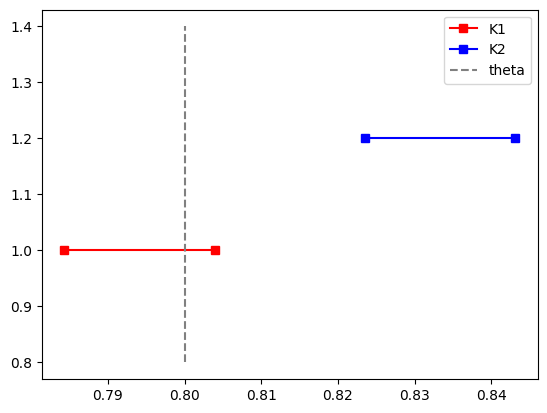

In [26]:
theta = 0.8
N1 = 50
N2 = 50

D1 = np.random.binomial(1, theta, N1)
n1 = count(1, D1)
D2 = np.random.binomial(1, theta, N2)
n2 = count(1, D2)

S = 1

K1 = [n1 / (N1 + S), (n1 + S) / (N1 + S)]
K2 = [n2 / (N2 + S), (n2 + S) / (N2 + S)]

intersec = intersection(K1, K2)
plt.plot(K1, [1, 1], "-", marker="s", color="red", label="K1")
plt.plot(K2, [1.2, 1.2], "-", marker="s", color="blue", label="K2")
plt.vlines(theta, 0.8, 1.4, colors="gray", linestyles="dashed", label="theta")

if intersec:
    K1_plus = [(n1 + S * K2[0]) / (N1 + S), (n1 + S * K2[1]) / (N1 + S)]
    K2_plus = [(n2 + S * K1[0]) / (N2 + S), (n2 + S * K1[1]) / (N2 + S)]

    plt.plot(K1_plus, [1.02, 1.02], "--", marker="s", color="red", label="K1_plus")
    plt.plot(K2_plus, [1.22, 1.22], "--", marker="s", color="blue", label="K2_plus")

    plt.fill_between(
        intersec, [0.8, 0.8], [1.4, 1.4], color="green", alpha=0.4, label="Intersection"
    )

plt.legend(loc="best")
plt.show()

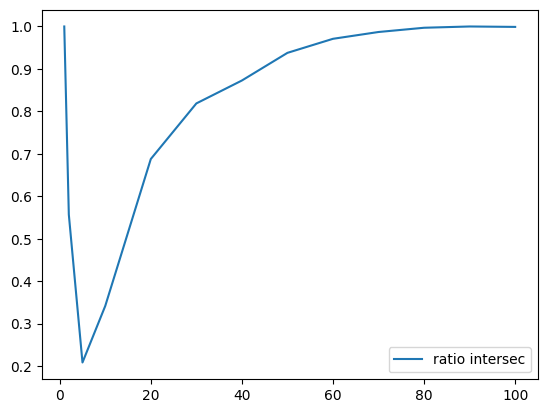

In [27]:
theta = 0.8
N1 = 50
N2 = 50

ratio_1 = []
ratio_2 = []
ratio_intersec = []

S_vec = [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
for S in S_vec:

    in_K1_plus = []
    in_K2_plus = []

    for _ in range(1000):

        D1 = np.random.binomial(1, theta, N1)
        D2 = np.random.binomial(1, theta, N2)

        n1 = count(1, D1)
        n2 = count(1, D2)

        K1 = [n1 / (N1 + S), (n1 + S) / (N1 + S)]
        K2 = [n2 / (N2 + S), (n2 + S) / (N2 + S)]

        if theta < K1[0] or theta < K2[0] or theta > K1[1] or theta > K2[1]:
            continue

        intersec = intersection(K1, K2)

        K1_plus = [(n1 + S * K2[0]) / (N1 + S), (n1 + S * K2[1]) / (N1 + S)]
        K2_plus = [(n2 + S * K1[0]) / (N2 + S), (n2 + S * K1[1]) / (N2 + S)]

        if theta >= K1_plus[0] and theta <= K1_plus[1]:
            in_K1_plus.append(True)
        else:
            in_K1_plus.append(False)
        if theta >= K2_plus[0] and theta <= K2_plus[1]:
            in_K2_plus.append(True)
        else:
            in_K2_plus.append(False)

    ratio_1.append(sum(in_K1_plus) / len(in_K1_plus))
    ratio_2.append(sum(in_K2_plus) / len(in_K2_plus))
    ratio_intersec.append(sum(in_K1_plus and in_K2_plus) / (len(in_K1_plus)))


# plt.plot(S_vec, ratio_1, label="ratio 1")
# plt.plot(S_vec, ratio_2, label="ratio 2")
plt.plot(S_vec, ratio_intersec, label="ratio intersec")
plt.legend(loc="best")

plt.show()

### On the merging of credal sets

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.spatial import ConvexHull
from fractions import Fraction
import cdd
import cdd.gmp
from itertools import product


def get_simplex_vertices():
    """
    Get the vertices of a unit 2D symplex.
    """
    h = np.sqrt(3) / 2
    v = np.array([[0.5, h], [0.0, 0.0], [1.0, 0.0]])  # t1 = 1  # t2 = 1  # t3 = 1
    return v


def plot_simplex(ax, vertices):
    simplex = Polygon(vertices, closed=True, fill=None, edgecolor="black", linewidth=2)
    ax.add_patch(simplex)

    # Vertex labels
    ax.text(
        vertices[0, 0],
        vertices[0, 1] + 0.02,
        "(1,0,0)",
        ha="center",
        va="bottom",
        fontsize=9,
    )
    ax.text(
        vertices[1, 0] - 0.02,
        vertices[1, 1],
        "(0,1,0)",
        ha="right",
        va="center",
        fontsize=9,
    )
    ax.text(
        vertices[2, 0] + 0.02,
        vertices[2, 1],
        "(0,0,1)",
        ha="left",
        va="center",
        fontsize=9,
    )

    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, np.sqrt(3) / 2 + 0.1)
    ax.set_aspect("equal")
    ax.axis("off")


def get_idm_bounds(counts, s):
    N = np.sum(counts)
    b1 = np.array([counts[0], counts[0] + s]) / (N + s)
    b2 = np.array([counts[1], counts[1] + s]) / (N + s)
    b3 = np.array([counts[2], counts[2] + s]) / (N + s)
    return np.array([b1, b2, b3])


# Get the credal set vertices from bounds
def get_vertices(vec_min, vec_max) -> np.array:

    # Define the (in)equalities (i.e., get the H-representation of the credal set)
    n_par = len(vec_min)
    A = np.concatenate(
        (-np.eye(n_par), np.eye(n_par), np.atleast_2d(np.ones(n_par))), axis=0
    )
    b = np.concatenate((vec_max, -vec_min, np.atleast_1d(-1))).reshape(len(A), 1)
    bA = np.concatenate((b, A), axis=1)
    bA_frac = np.array(
        [[Fraction(x).limit_denominator() for x in row] for row in bA], dtype=object
    )  # Needed for numerical stability
    mat_frac = cdd.gmp.matrix_from_array(
        array=bA_frac, rep_type=cdd.RepType.INEQUALITY, lin_set=set([len(A) - 1])
    )

    # Get the polytope and extreme points. Each point is a row of the matrix `vertices`
    poly_frac = cdd.gmp.polyhedron_from_matrix(mat_frac)
    ext_frac = cdd.gmp.copy_generators(poly_frac)
    vertices_frac = np.array(ext_frac.array)[:, 1:]
    vertices = np.array([[float(x) for x in row] for row in vertices_frac], dtype=float)

    # Debug
    safe_assert(len(b) == 2 * len(vec_min) + 1)
    safe_assert(A.shape == (len(b), len(vec_min)))
    safe_assert(bA.shape == (2 * len(vec_min) + 1, len(vec_min) + 1))
    safe_assert(vertices.shape[1] == n_par)

    return vertices


def project_3d_to_2d(p_3d, vertices_2d):
    return (
        p_3d[0] * vertices_2d[0] + p_3d[1] * vertices_2d[1] + p_3d[2] * vertices_2d[2]
    )


def draw_poly(
    ax, vertices, simplex_2d, color, label="", alpha=0.4, project=True, edgecolor=None
):
    kwargs = {
        "closed": True,
        "facecolor": color,
        "alpha": alpha,
        "label": label,
        "linestyle": "--",
        "edgecolor": edgecolor,
    }
    if project:
        pts_2d = np.array([project_3d_to_2d(v, simplex_2d) for v in vertices])
        hull = ConvexHull(pts_2d)
        poly = Polygon(pts_2d[hull.vertices], **kwargs)
    else:
        poly = Polygon(vertices, **kwargs)
    ax.add_patch(poly)

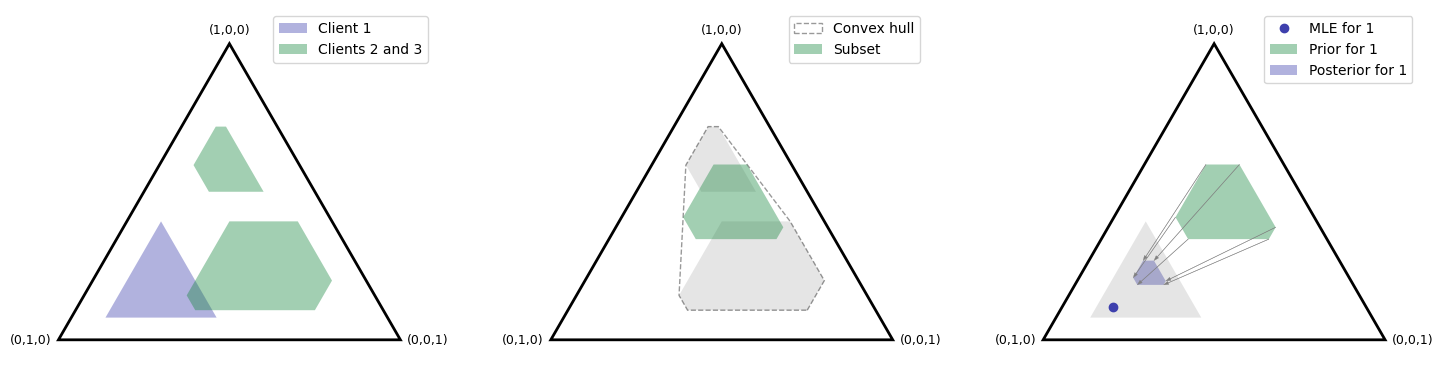

In [36]:
# Simplex
simplex = get_simplex_vertices()

# Counts
n1 = np.array([3, 20, 4])
N = np.sum(n1)
mle = n1 / np.sum(n1)
mle_2d = project_3d_to_2d(mle, simplex)

# Credal set (IDM)
s = 13
bounds = get_idm_bounds(n1, s)
vertices = get_vertices(bounds[:, 0], bounds[:, 1])

# Priors
p1_bounds = np.array([[0.1, 0.4], [0.1, 0.55], [0.3, 0.7]])
p1_vertices = get_vertices(p1_bounds[:, 0], p1_bounds[:, 1])
p2_bounds = np.array([[0.5, 0.72], [0.15, 0.31], [0.1, 0.68]])
p2_vertices = get_vertices(p2_bounds[:, 0], p2_bounds[:, 1])

p1_2d = np.array([project_3d_to_2d(p, simplex) for p in p1_vertices])
p2_2d = np.array([project_3d_to_2d(p, simplex) for p in p2_vertices])
w = 0.4
p_comb_vertices = []
for i in p1_2d:
    for j in p2_2d:
        p_comb_vertices += [w * i + (1 - w) * j]
hull = ConvexHull(p_comb_vertices)
p_comb = hull.points[hull.vertices]

# Convex hull of xternal c-sets
c_hull_ext = ConvexHull(np.append(p1_2d, p2_2d, axis=0))
c_hull_pts = c_hull_ext.points[c_hull_ext.vertices]

# Posterior
posterior_vertices = (s / (N + s)) * p_comb + (N / (N + s)) * mle_2d

## Plots
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# 1
plot_simplex(axs[0], simplex)
simplex = get_simplex_vertices()
draw_poly(axs[0], vertices, simplex, color="#3e40ad", label="Client 1")
draw_poly(axs[0], p1_vertices, simplex, color="#18873f", label="Clients 2 and 3")
draw_poly(axs[0], p2_vertices, simplex, color="#18873f")

axs[0].legend(loc="best")

# 2
plot_simplex(axs[1], simplex)
simplex = get_simplex_vertices()
draw_poly(axs[1], p1_vertices, simplex, color="gray", alpha=0.2)
draw_poly(axs[1], p2_vertices, simplex, color="gray", alpha=0.2)
draw_poly(
    axs[1],
    c_hull_pts,
    simplex,
    project=False,
    color="none",
    edgecolor="black",
    label="Convex hull",
)
draw_poly(axs[1], p_comb, simplex, color="#18873f", project=False, label="Subset")

axs[1].legend(loc="best")

# 3
plot_simplex(axs[2], simplex)
simplex = get_simplex_vertices()
axs[2].plot(mle_2d[0], mle_2d[1], "o", color="#3e40ad", label="MLE for 1")
draw_poly(axs[2], p_comb, simplex, color="#18873f", project=False, label="Prior for 1")
draw_poly(
    axs[2],
    posterior_vertices,
    simplex,
    color="#3e40ad",
    project=False,
    label="Posterior for 1",
)
draw_poly(axs[2], vertices, simplex, color="gray", alpha=0.2)

for i in range(len(p_comb)):
    prior_v = p_comb[i, :]
    post_v = posterior_vertices[i, :]
    axs[2].arrow(
        prior_v[0],
        prior_v[1],
        post_v[0] - prior_v[0],
        post_v[1] - prior_v[1],
        head_width=0.01,
        head_length=0.015,
        fc="gray",
        ec="gray",
        alpha=1,
        length_includes_head=True,
        linewidth=0.2,
    )

axs[2].legend(loc="best")

plt.show()

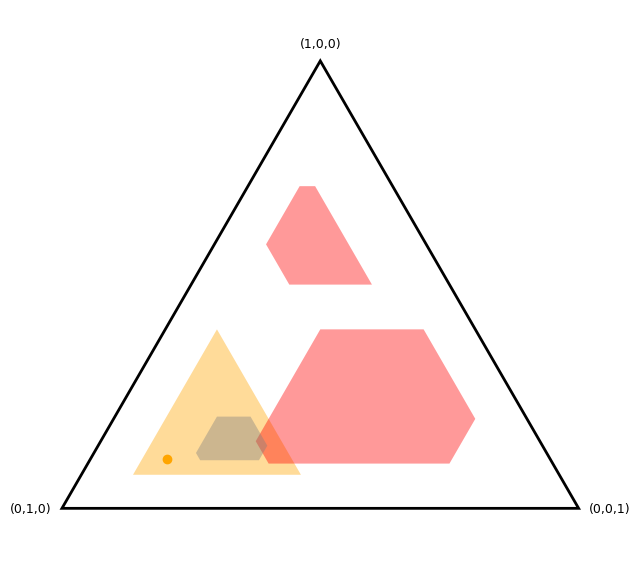

In [30]:
# Simplex
simplex = get_simplex_vertices()

# Counts
n1 = np.array([3, 20, 4])
N = np.sum(n1)
mle = n1 / np.sum(n1)
mle_2d = project_3d_to_2d(mle, simplex)

# Credal set (IDM)
s = 13
bounds = get_idm_bounds(n1, s)
vertices = get_vertices(bounds[:, 0], bounds[:, 1])

# Priors
p1_bounds = np.array([[0.1, 0.4], [0.1, 0.55], [0.3, 0.7]])
p1_vertices = get_vertices(p1_bounds[:, 0], p1_bounds[:, 1])
p2_bounds = np.array([[0.5, 0.72], [0.15, 0.31], [0.1, 0.68]])
p2_vertices = get_vertices(p2_bounds[:, 0], p2_bounds[:, 1])

p1_2d = np.array([project_3d_to_2d(p, simplex) for p in p1_vertices])
p2_2d = np.array([project_3d_to_2d(p, simplex) for p in p2_vertices])

hull = ConvexHull(p1_2d)
p_comb = hull.points[hull.vertices]

# Posterior
posterior_vertices = (s / (N + s)) * p_comb + (N / (N + s)) * mle_2d

# Plot
fig, axs = plt.subplots(1, 1, figsize=(8, 8))

plot_simplex(axs, simplex)
simplex = get_simplex_vertices()
draw_poly(axs, vertices, simplex, color="orange")
draw_poly(axs, p1_vertices, simplex, color="red")
draw_poly(axs, p2_vertices, simplex, color="red")
draw_poly(axs, posterior_vertices, simplex, color="gray", project=False)
axs.plot(mle_2d[0], mle_2d[1], "o", color="orange")

plt.show()